In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72

import gensim
from gensim.models import Word2Vec
from nltk.corpus import abc

print(f'gensim version= {gensim.__version__}')

gensim version= 4.4.0


In [7]:
%%time

sents = list(abc.sents())

model = Word2Vec(abc.sents(), min_count=2, workers=4)
X = list(model.wv.index_to_key)

# Sanity
print(f'ABC dataset has {len(sents)} sentences')
print(f'gensim model vocabulary has {len(X)} words mapped to N= {model.vector_size} dimensions')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


ABC dataset has 29059 sentences
gensim model vocabulary has 19484 words mapped to N= 100 dimensions
CPU times: user 10.6 s, sys: 302 ms, total: 10.9 s
Wall time: 6.66 s


In [8]:
# The closest words to the word 'science'
science = model.wv.most_similar('science')
print(science)

[('agriculture', 0.9642693996429443), ('law', 0.9424976706504822), ('management', 0.9382252097129822), ('improvement', 0.9373003244400024), ('bulk', 0.9371849894523621), ('education', 0.9369526505470276), ('fishing', 0.9363412261009216), ('policy', 0.9354428052902222), ('biosecurity', 0.9350360035896301), ('festival', 0.9344764351844788)]


In [9]:
# Distance between computer and science
science12 = model.wv.similarity('science', 'computer')
print(science12)

0.7894823


In [12]:
from nltk.corpus import gutenberg

sents = list(gutenberg.sents('shakespeare-hamlet.txt'))
print(sents[0])

['[', 'The', 'Tragedie', 'of', 'Hamlet', 'by', 'William', 'Shakespeare', '1599', ']']


In [13]:
%%time

# CBOW model
model1 = Word2Vec(sents, vector_size=200, sg=0, window=13, min_count=1, epochs=20, workers=4)

# Skip-gram model
model2 = Word2Vec(sents, vector_size=200, sg=1, window=13, min_count=1, epochs=20, workers=4)

CPU times: user 8.81 s, sys: 131 ms, total: 8.94 s
Wall time: 2.92 s


In [14]:
similarities1b = model1.wv.most_similar(positive=['Hamlet'], topn=20)
similarities1 = model1.wv.most_similar(positive=['Hamlet', 'Ophelia', 'Ghost'], topn=20)
similarities2 = model2.wv.most_similar(positive=['Hamlet', 'Ophelia', 'Ghost'], topn=20)

In [15]:
# Clean the stop words   
def filter_words(_sim):
    from nltk.corpus import stopwords
    import re
    stop_words = set(stopwords.words('english'))
    return [(w,p) for w,p in _sim if w.lower() not in stop_words and re.search(r'^[a-zA-Z]{3,}$',w) is not None]

similarities1b = filter_words(similarities1b)
similarities1 = filter_words(similarities1)
similarities2 = filter_words(similarities2)

In [16]:
for (w1,s1),(w1b,s1b),(w2,s2) in zip(similarities1, similarities1b, similarities2):
    print(f'{w1:16s}{s1:.3f}\t\t{w1b:16s}{s1b:.3f}\t\t{w2:16s}{s2:.3f}')

Horatio         0.996		Ghost           0.993		Rosincrane      0.891
Voltumand       0.991		Horatio         0.992		Claudius        0.849
Cornelius       0.991		Ophelia         0.992		Voltumand       0.835
Welcome         0.990		Manet           0.986		Sister          0.826
slaine          0.990		Voltumand       0.984		Manet           0.822
Thankes         0.990		Cornelius       0.983		Attendant       0.821
Guard           0.990		slaine          0.983		Polonius        0.818
Barnardo        0.989		Welcome         0.983		beckens         0.818
gentle          0.988		Booke           0.982		Gertrude        0.815
Manet           0.988		Rosincrane      0.982		Osricke         0.812
Osricke         0.988		Marcellus       0.981		Laertes         0.812
Reynoldo        0.988		Thankes         0.981		Marcellus       0.808
Booke           0.988		Guard           0.981		Queene          0.803
Dane            0.987		Barnardo        0.980		denies          0.801
twaine          0.987		Osricke         0.980		Gu

In [17]:
# The word embedding matrix
words1a = [w for w,s in similarities1] + ['Hamlet']
X1a = model1.wv[words1a]

words2a = [w for w,s in similarities2] + ['Hamlet']
X2a = model2.wv[words2a]

# Sanity
print(X1a.shape)

(20, 200)


In [18]:
from sklearn.decomposition import PCA

pca_model1a = PCA(n_components=2).fit_transform(X1a)
pca_model2a = PCA(n_components=2).fit_transform(X2a)

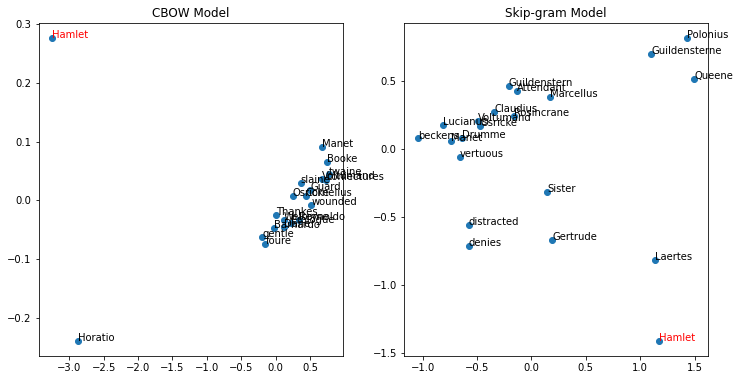

In [19]:
def plot_pca(_pca_model, _words, _title):
    plt.scatter(_pca_model[:, 0], _pca_model[:, 1])
    for i, word in enumerate(_words):
        plt.annotate(word, xy=(_pca_model[i, 0], _pca_model[i, 1]), c=('r' if word=='Hamlet' else 'k'))
    plt.title(_title)

plt.figure(figsize=(12, 6), dpi=72)
    
_ = plt.subplot(1, 2, 1)
plot_pca(pca_model1a, words1a, 'CBOW Model')

_ = plt.subplot(1, 2, 2)
plot_pca(pca_model2a, words2a, 'Skip-gram Model')

plt.show()

In [20]:
dissimilarities1 = model1.wv.most_similar(negative=['Hamlet'], topn=20)
dissimilarities2 = model2.wv.most_similar(negative=['Hamlet'], topn=20)

words1b = ['Hamlet'] + [w for w,s in similarities1] + [w for w,s in dissimilarities1]

X1b = model1.wv[words1b]

words2b = ['Hamlet'] + [w for w,s in similarities2] + [w for w,s in dissimilarities2]

X2b = model2.wv[words2b]

pca_model1b = PCA(n_components=2).fit_transform(X1b)
pca_model2b = PCA(n_components=2).fit_transform(X2b)

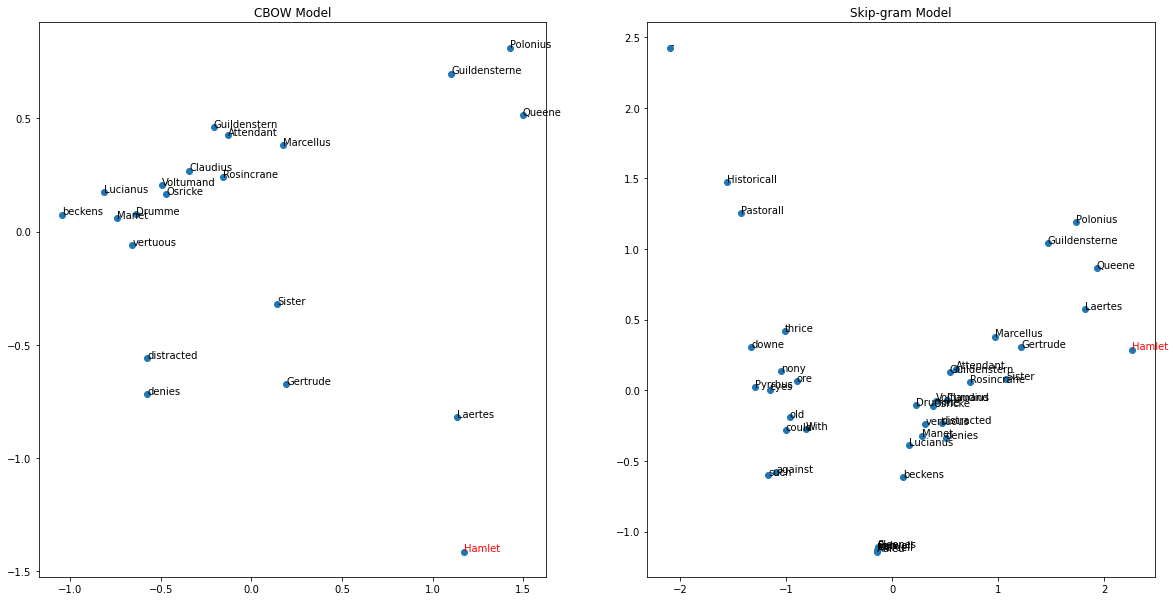

In [21]:
plt.figure(figsize=(20, 10), dpi=72)

_ = plt.subplot(1, 2, 1)
plot_pca(pca_model2a, words2a, 'CBOW Model')

_ = plt.subplot(1, 2, 2)
plot_pca(pca_model2b, words2b, 'Skip-gram Model')

plt.show()

In [22]:
print(model1.wv.most_similar(positive=['Alas', 'poor', 'Yorick', 'Horatio'], topn=20))

[('Are', 0.9934191703796387), ('Who', 0.9933391809463501), ('sayes', 0.992629885673523), ('Lady', 0.992431104183197), ('teares', 0.9923200607299805), ('ee', 0.9917195439338684), ('sore', 0.9916749596595764), ('ground', 0.9915953278541565), ('fie', 0.9915637373924255), ('digge', 0.9915255308151245), ('Scripture', 0.9914673566818237), ('Too', 0.9914281368255615), ('art', 0.9914136528968811), ('Where', 0.991228461265564), ('Taske', 0.9911423921585083), ('wed', 0.9910745024681091), ('Noble', 0.9910433292388916), ('Thou', 0.9909950494766235), ('solemne', 0.990699052810669), ('entertainment', 0.9905746579170227)]


In [23]:
print(model1.wv.most_similar(negative=['Alas', 'poor', 'Yorick', 'Horatio'], topn=20))

[('Scourge', 0.9161766767501831), ('Minister', 0.9134607315063477), ('Lookes', 0.9030249714851379), ('punish', 0.8851096034049988), ('Rood', 0.8705808520317078), ('threats', 0.8531560301780701), ('Abstracts', 0.8394217491149902), ('Asking', 0.8151037096977234), ('Offer', 0.8105912208557129), ('adoption', 0.7876956462860107), ('Precepts', 0.7604274153709412), ('image', 0.7323060035705566), ('Fixion', 0.7304113507270813), ('humble', 0.7201904058456421), ('trifling', 0.7041603922843933), ('Cause', 0.6694021224975586), ('Doctor', 0.65827876329422), ('Came', 0.6489191055297852), ('Romage', 0.6448804140090942), ('Armour', 0.6398084163665771)]
